### PHÂN TÍCH GIẤC NGỦ & ĐẶC ĐIỂM CÁ NHÂN TÁC ĐỘNG ĐẾN KẾT QUẢ THI

**Câu hỏi nghiên cứu:** Lối sống (giấc ngủ, internet) và đặc điểm cá nhân (tuổi, giới tính) có liên quan như thế nào đến điểm thi của học sinh?

PHÂN TÍCH GIẤC NGỦ & ĐẶC ĐIỂM CÁ NHÂN TÁC ĐỘNG ĐẾN ĐIỂM THI

--- 1. BẢNG THỐNG KÊ ĐIỂM THI THEO NHÓM GIỜ NGỦ ---
  sleep_group  count       mean
0        4-5h   3460  59.232035
1        6-7h   6656  61.054900
2        8-9h   6656  63.832265
3        10h+   3228  66.317437


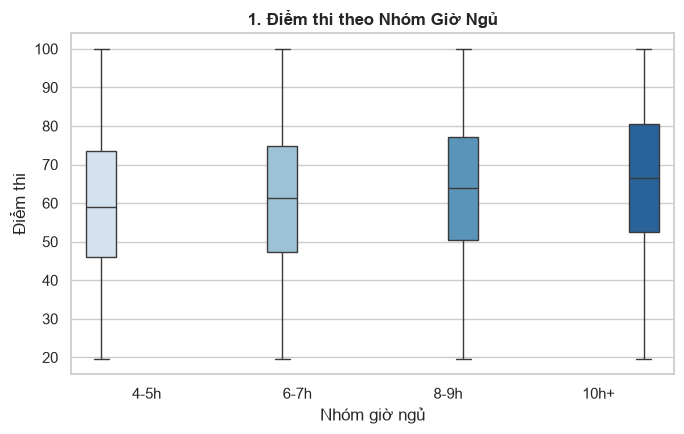


--- 2. BẢNG THỐNG KÊ ĐIỂM THI THEO CHẤT LƯỢNG GIẤC NGỦ ---
  sleep_quality  count       mean
0       average   6694  62.530512
1          good   6619  67.138598
2          poor   6687  57.917582


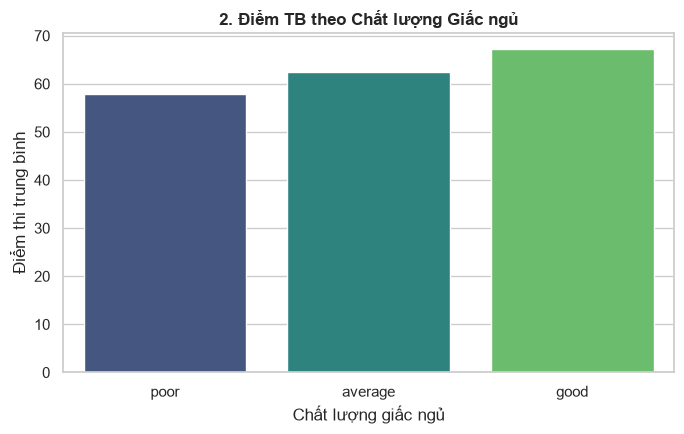


--- 3. BẢNG THỐNG KÊ ĐIỂM THI THEO INTERNET ACCESS ---
  internet_access  count       mean
0              no   3012  62.864663
1             yes  16988  62.450914


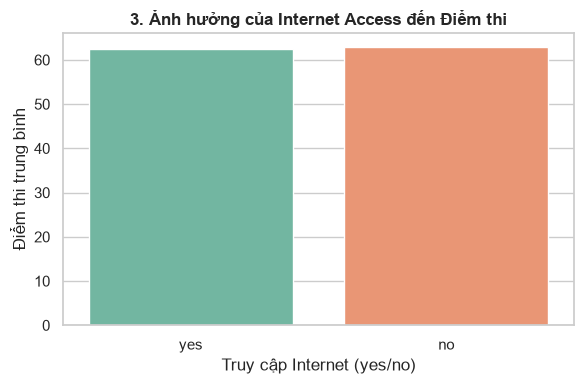


--- 4. HỆ SỐ TƯƠNG QUAN (CORRELATION) GIỮA AGE VÀ EXAM SCORE: 0.0065 ---


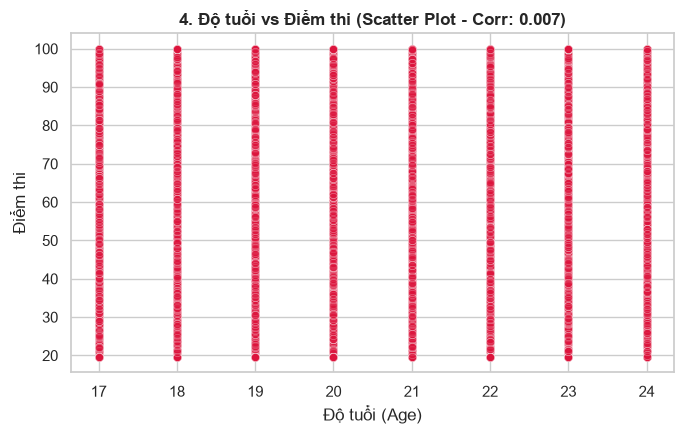


--- 5. BẢNG THỐNG KÊ ĐIỂM THI THEO GIỚI TÍNH ---
   gender  count       mean
0  female   6579  62.582145
1    male   6695  62.397480
2   other   6726  62.561023


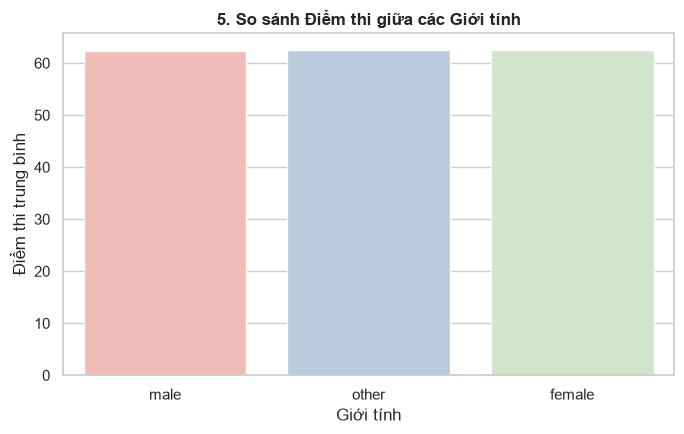

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. THIẾT LẬP GIAO DIỆN & TẮT CẢNH BÁO
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# 2. ĐỌC DỮ LIỆU GỐC (Đường dẫn tương đối ra thư mục cha)
df = pd.read_csv('../Student_Score_Analysis/data/Exam_Score_Prediction.csv')

print("="*60)
print("PHÂN TÍCH GIẤC NGỦ & ĐẶC ĐIỂM CÁ NHÂN TÁC ĐỘNG ĐẾN ĐIỂM THI")
print("="*60)

# ==============================================================================
# 1. SLEEP HOURS -> EXAM SCORE
# ==============================================================================
print("\n--- 1. BẢNG THỐNG KÊ ĐIỂM THI THEO NHÓM GIỜ NGỦ ---")
df['sleep_group'] = pd.cut(df['sleep_hours'], bins=[3, 5, 7, 9, 11], labels=['4-5h', '6-7h', '8-9h', '10h+'])
sleep_table = df.groupby('sleep_group', observed=False)['exam_score'].agg(['count', 'mean']).reset_index()
print(sleep_table)

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x='sleep_group', y='exam_score', hue='sleep_group', palette='Blues', legend=False)
plt.title('1. Điểm thi theo Nhóm Giờ Ngủ', fontweight='bold')
plt.xlabel('Nhóm giờ ngủ')
plt.ylabel('Điểm thi')
plt.tight_layout()
plt.savefig('fig1_sleep_hours_boxplot.png', dpi=300)
plt.show()

# ==============================================================================
# 2. SLEEP QUALITY -> EXAM SCORE
# ==============================================================================
print("\n--- 2. BẢNG THỐNG KÊ ĐIỂM THI THEO CHẤT LƯỢNG GIẤC NGỦ ---")
qual_table = df.groupby('sleep_quality')['exam_score'].agg(['count', 'mean']).reset_index()
print(qual_table)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=df, x='sleep_quality', y='exam_score', order=['poor', 'average', 'good'], hue='sleep_quality', palette='viridis', errorbar=None, legend=False)
plt.title('2. Điểm TB theo Chất lượng Giấc ngủ', fontweight='bold')
plt.xlabel('Chất lượng giấc ngủ')
plt.ylabel('Điểm thi trung bình')
plt.tight_layout()
plt.savefig('fig2_sleep_quality_bar.png', dpi=300)
plt.show()

# ==============================================================================
# 3. INTERNET ACCESS -> EXAM SCORE
# ==============================================================================
print("\n--- 3. BẢNG THỐNG KÊ ĐIỂM THI THEO INTERNET ACCESS ---")
net_table = df.groupby('internet_access')['exam_score'].agg(['count', 'mean']).reset_index()
print(net_table)

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='internet_access', y='exam_score', hue='internet_access', palette='Set2', errorbar=None, legend=False)
plt.title('3. Ảnh hưởng của Internet Access đến Điểm thi', fontweight='bold')
plt.xlabel('Truy cập Internet (yes/no)')
plt.ylabel('Điểm thi trung bình')
plt.tight_layout()
plt.savefig('fig3_internet_access_bar.png', dpi=300)
plt.show()

# ==============================================================================
# 4. AGE -> EXAM SCORE
# ==============================================================================
age_corr = df['age'].corr(df['exam_score'])
print(f"\n--- 4. HỆ SỐ TƯƠNG QUAN (CORRELATION) GIỮA AGE VÀ EXAM SCORE: {age_corr:.4f} ---")

plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df, x='age', y='exam_score', color='crimson', alpha=0.4)
plt.title(f'4. Độ tuổi vs Điểm thi (Scatter Plot - Corr: {age_corr:.3f})', fontweight='bold')
plt.xlabel('Độ tuổi (Age)')
plt.ylabel('Điểm thi')
plt.tight_layout()
plt.savefig('fig4_age_scatter.png', dpi=300)
plt.show()

# ==============================================================================
# 5. GENDER -> EXAM SCORE
# ==============================================================================
print("\n--- 5. BẢNG THỐNG KÊ ĐIỂM THI THEO GIỚI TÍNH ---")
gender_table = df.groupby('gender')['exam_score'].agg(['count', 'mean']).reset_index()
print(gender_table)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=df, x='gender', y='exam_score', hue='gender', palette='Pastel1', errorbar=None, legend=False)
plt.title('5. So sánh Điểm thi giữa các Giới tính', fontweight='bold')
plt.xlabel('Giới tính')
plt.ylabel('Điểm thi trung bình')
plt.tight_layout()
plt.savefig('fig5_gender_bar.png', dpi=300)
plt.show()

### INSIGHTS & KẾT LUẬN CHO CÂU HỎI NGHIÊN CỨU:

* **1. Số giờ ngủ (`sleep_hours`):** Học sinh ngủ đủ từ **8–9 giờ/ngày** và **10h+** đạt điểm thi trung bình cao nhất (~63.8 - 66.3 điểm). Thức khuya ngủ ít (4–5h) làm giảm đáng kể kết quả thi (chỉ đạt ~59.2 điểm).
* **2. Chất lượng giấc ngủ (`sleep_quality`):** Chất lượng ngủ tác động rất lớn. Nhóm ngủ tốt (`good`) đạt điểm trung bình cao nhất (~67.1 điểm), vượt trội rõ rệt so với nhóm ngủ kém (`poor` - ~57.9 điểm).
* **3. Internet Access (`internet_access`):** Việc có hay không có Internet tại nhà hầu như không tạo ra chênh lệch điểm số (cả 2 nhóm `yes` và `no` đều xấp xỉ ~62.5 điểm).
* **4. Độ tuổi (`age`):** Độ tuổi (từ 17 đến 24) không có tương quan hay ảnh hưởng nào đến kết quả thi (hệ số tương quan r ≈ 0.0065 cực kỳ yếu).
* **5. Giới tính (`gender`):** Giới tính hoàn toàn không tác động đến điểm số. Học sinh Nam (`male`), Nữ (`female`) và Giới tính khác (`other`) đạt điểm trung bình hoàn toàn tương đương nhau (~62.4 - 62.5 điểm).
---
📌 **KẾT LUẬN CHUNG:** Lối sống (thời lượng và chất lượng giấc ngủ) có ảnh hưởng mạnh mẽ nhất tới kết quả thi của học sinh. Ngược lại, việc dùng Internet và các đặc điểm cá nhân (tuổi, giới tính) hoàn toàn không quyết định đến điểm số.